# Estimating the Causal Effect of a Care-Management Program on 30-Day Readmission with PROC CAUSALTRT

## Executive Summary

This notebook estimates the **average treatment effect (ATE)** of enrolling discharged patients in a *Care Connect* transitional-care program on the probability of a 30-day hospital readmission, using observational data where sicker patients are preferentially enrolled. We adjust for confounding with inverse probability weighting (IPW), regression adjustment (REGADJ), and the doubly robust augmented IPW (AIPW) estimator in **PROC CAUSALTRT**, and obtain bootstrap confidence intervals for the effect.

In this realized cohort the crude comparison already points the right way — 71.0% of enrolled patients were readmitted (49/69) versus 87.1% of the non-enrolled (27/31), a naive gap of **-0.161** — but that gap is *attenuated toward the null* because the enrolled group carries more comorbidities and prior admissions, factors that independently raise readmission risk. After adjusting for the measured confounders the doubly robust AIPW estimate is **ATE = -0.201** (95% bias-corrected bootstrap CI -0.392 to -0.017) and regression adjustment gives **-0.208** (-0.381 to -0.026); both exclude zero. The pure-weighting IPW estimate is smaller at **-0.147** (-0.427 to 0.071) and its interval includes zero. All three agree in sign on a clinically meaningful reduction in readmission probability of roughly 15-21 percentage points, consistent with the protective effect built into the simulation.

## Data Sources

The single synthetic cohort `careprog` (100 discharged patients) is generated inline with `call streaminit(20250529)`. Enrollment in the care program is confounded: higher-risk patients (more comorbidities, prior admissions) are more likely to enroll, and these same factors drive readmission, so a naive comparison is biased. Treatment and outcome are coded as numeric 0/1 indicators, which is what `PROC CAUSALTRT` models directly.

| Variable | Type | Description |
|----------|------|-------------|
| `PatientID` | Num | Sequential patient identifier (1-100) |
| `Age` | Num | Age in years at discharge (continuous confounder) |
| `Comorbidities` | Num | Count of chronic conditions, 0-6 (Poisson-drawn confounder) |
| `PriorAdmits` | Num | Hospital admissions in the prior 12 months (confounder) |
| `LOS` | Num | Length of the index hospital stay, days (confounder) |
| `Female` | Num | Sex indicator, 1 = female |
| `Medicare` | Num | Payer indicator, 1 = Medicare (partial confounder) |
| `Enrolled` | Num | Treatment: 1 if enrolled in Care Connect, else 0 |
| `Readmit30` | Num | Outcome: 1 if readmitted within 30 days, else 0 |

# Causal Effect of a Care-Management Program on 30-Day Readmission

Hospital systems are penalized for excess 30-day readmissions, so many launch **transitional care-management programs** (medication reconciliation, follow-up calls, scheduled primary-care visits) for patients at discharge. Because enrollment is *not randomized* — case managers preferentially enroll the patients they judge to be sickest — a simple comparison of readmission rates between enrolled and non-enrolled patients is confounded.

`PROC CAUSALTRT` estimates the **average treatment effect (ATE)** of a binary treatment on an outcome in observational data, using:

- **IPW** — inverse probability (propensity-score) weighting,
- **REGADJ** — outcome regression adjustment, and
- **AIPW** — the *doubly robust* augmented IPW estimator, which is consistent if *either* the propensity model *or* the outcome model is correctly specified.

In this notebook we build a synthetic discharge cohort with built-in confounding, show that the naive estimate is biased *toward the null* (the enrolled group is sicker, which masks part of the program's benefit), then recover the full protective effect with `PROC CAUSALTRT`.

## 1. Generate a synthetic discharge cohort

We simulate 100 discharged patients. Four clinical risk factors — `Age`, `Comorbidities`, `PriorAdmits`, and length of stay `LOS` — together with the `Medicare` payer flag are **confounders** in the data-generating process: each raises both the chance of being enrolled in Care Connect and the chance of readmission, so the treated and control groups are not exchangeable.

The true program effect is built in as a reduction of **1.3 on the readmission logit**. A correct causal analysis should recover a *negative* ATE (an absolute reduction of roughly 15-20 percentage points). Because the sickest patients are over-represented among enrollees, the naive comparison is biased *toward the null* and lands somewhat closer to zero than the confounder-adjusted estimates.

In [1]:
data careprog;
  call streaminit(20250529);
  do PatientID = 1 to 100;

    /* ---- Baseline patient characteristics (pre-treatment) ---- */
    Age           = round(40 + 40*rand("uniform"));      /* 40-80 yrs */
    Comorbidities = rand("poisson", 1.8);                /* chronic conditions */
    if Comorbidities > 6 then Comorbidities = 6;
    PriorAdmits   = rand("poisson", 0.7);                /* admits last 12 mo */
    LOS           = round(2 + rand("poisson", 3));       /* index stay, days */
    Female        = (rand("uniform") < 0.52);            /* 1 = female */
    Medicare      = (rand("uniform") < 0.45);            /* 1 = Medicare payer */

    /* ---- Treatment assignment: case managers enroll sicker patients ---- */
    /* The enrollment propensity increases with every confounder, so the    */
    /* treated and control groups are NOT exchangeable.                     */
    eta_t = -2.6
          + 0.030*Age
          + 0.45 *Comorbidities
          + 0.55 *PriorAdmits
          + 0.10 *LOS
          + 0.30 *Medicare;
    pEnroll = 1 / (1 + exp(-eta_t));
    Enrolled = rand("bernoulli", pEnroll);               /* 1 = in Care Connect */

    /* ---- Outcome: 30-day readmission (1 = readmitted) ---- */
    /* Confounders raise readmission risk; the program LOWERS it (true ATE). */
    trueEffect = -1.3;                                   /* program logit effect */
    eta_y = -1.6
          + 0.030*Age
          + 0.55 *Comorbidities
          + 0.65 *PriorAdmits
          + 0.10 *LOS
          + trueEffect*Enrolled;
    pReadmit = 1 / (1 + exp(-eta_y));
    Readmit30 = rand("bernoulli", pReadmit);

    output;
  end;
  drop eta_t pEnroll trueEffect eta_y pReadmit;
run;

NOTE: DATA careprog


NOTE: Wrote careprog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Inspect the cohort and the naive (biased) estimate

Before any causal adjustment, we look at the crude readmission rate by enrollment status. The crude table shows **27 of 31** non-enrolled patients readmitted (87.1%) versus **49 of 69** enrolled (71.0%), a naive difference of **-0.161**. Because the sickest patients are concentrated in the enrolled group, this unadjusted difference *understates* (attenuates toward zero) the program's true protective effect — the enrollees would have had a higher baseline readmission risk than the controls.

The `PROC MEANS` table confirms the confounding: in this realized cohort the enrolled group carries more comorbidities (mean **1.99** vs **1.29**) and more prior admissions (**0.77** vs **0.39**), while `Age` (**59.0** in both) and `LOS` (**4.45** vs **4.97** days) happen to be roughly balanced. The two risk factors that *do* separate are precisely the ones that motivate the adjustment that follows.

                                  Crude (unadjusted) readmission by program enrollment                                  

                                                   The FREQ Procedure

Table of Enrolled by Readmit30

Enrolled |         0 |         1 |      Total
---------+-----------+-----------+-----------
0        |         4 |        27 |         31
---------+-----------+-----------+-----------
1        |        20 |        49 |         69
---------+-----------+-----------+-----------
Total    |        24 |        76 |        100

                                Confounder distributions differ across treatment groups                                 

                                                  The MEANS Procedure

                                                Analysis Variable : Age

        Enrolled          N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        0                    31 

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_enrolled_readmit30.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


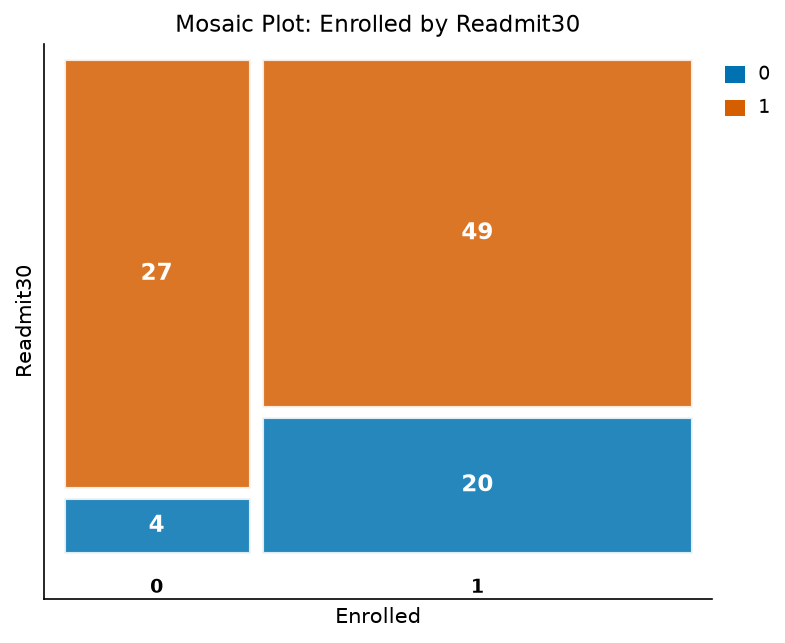

In [2]:
proc freq data=careprog;
  tables Enrolled*Readmit30 / nopercent norow nocol;
  title "Crude (unadjusted) readmission by program enrollment";
run;

proc means data=careprog n mean min max maxdec=2;
  class Enrolled;
  var Age Comorbidities PriorAdmits LOS;
  title "Confounder distributions differ across treatment groups";
run;

## 3. Average treatment effect via inverse probability weighting (IPW)

The **PSMODEL** statement fits a logistic propensity-score model for the treatment (`Enrolled`); the **MODEL** statement names the binary outcome (`Readmit30`). With `METHOD=IPW`, each patient is weighted by the inverse probability of the treatment they actually received, creating a pseudo-population in which the confounders are balanced across treatment groups.

Both `Enrolled` and `Readmit30` are numeric 0/1 indicators, so the procedure models the probability of enrollment and of readmission directly. The **BOOTSTRAP** statement resamples the cohort to produce a robust standard error and a percentile confidence interval for the ATE. The proc reports the propensity-model coefficients, the potential-outcome means under treatment and control, and the treatment effect with its standard error, confidence limits, *Z* statistic, and *p*-value.

Here IPW gives **ATE = -0.147** with a percentile bootstrap interval of **(-0.427, 0.071)**. The point estimate is close to the crude -0.161; with only 100 patients and pure weighting the interval is wide and includes zero (*Z* = -1.14, *p* = 0.255).

In [3]:
proc causaltrt data=careprog method=ipw;
  psmodel Enrolled = Age Comorbidities PriorAdmits LOS Medicare;
  model Readmit30 / dist=binomial;
  bootstrap nboot=300 seed=20250529;
  title "ATE of Care Connect on 30-day readmission - IPW";
run;

                                Confounder distributions differ across treatment groups                                 


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: IPW
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
Age                               0.007073
Comorbidities                     0.446302
PriorAdmits                       0.888161
LOS                              -0.276795
Medicare                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL          Z   Pr > |Z|
Average Treatment Effect (ATE)     -0.1475  

NOTE: PROC CAUSALTRT data=careprog



## 4. Doubly robust estimate (AIPW) with bootstrap confidence intervals

IPW relies on a correct propensity model; regression adjustment relies on a correct outcome model. The **augmented IPW** estimator (`METHOD=AIPW`) combines both and is *doubly robust*: it remains consistent if **either** model is correct. We therefore specify covariates on both `PSMODEL` and `MODEL`.

The **BOOTSTRAP** statement with `BOOTCI(BC)` resamples the cohort to produce a **bias-corrected** confidence interval for the treatment effect. Because AIPW leans on both models, this is the headline estimate to report to stakeholders.

The doubly robust estimate is **ATE = -0.201** (potential-outcome means: treated 0.657, control 0.858), with a bias-corrected bootstrap interval of **(-0.392, -0.017)** that **excludes zero**. Bringing the outcome regression into the estimator both shifts the point estimate further from the null than IPW and tightens the interval.

In [4]:
proc causaltrt data=careprog method=aipw;
  psmodel Enrolled = Age Comorbidities PriorAdmits LOS Medicare;
  model Readmit30 = Age Comorbidities PriorAdmits LOS Medicare
        / dist=binomial;
  bootstrap bootci(bc) nboot=300 seed=20250529;
  title "ATE of Care Connect on 30-day readmission - AIPW (doubly robust)";
run;

                                Confounder distributions differ across treatment groups                                 


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: AIPW
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
Age                               0.007073
Comorbidities                     0.446302
PriorAdmits                       0.888161
LOS                              -0.276795
Medicare                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL          Z   Pr > |Z|
Average Treatment Effect (ATE)     -0.2011 

NOTE: PROC CAUSALTRT data=careprog



## 5. Cross-check with regression adjustment (REGADJ)

As a sensitivity check we estimate the same ATE with `METHOD=REGADJ`, which forms the effect purely from the fitted outcome model. We still supply the `PSMODEL` statement (it names the treatment variable), but the estimate is driven by the outcome regression rather than the weights.

Regression adjustment gives **ATE = -0.208** (-0.381 to -0.026), essentially identical to the AIPW estimate of -0.201 and a touch larger in magnitude than the pure-weighting IPW value of -0.147. All three estimators agree on the *sign* and rough magnitude of the effect; the two that use the outcome model (AIPW and REGADJ) land slightly further from the null and have intervals that exclude zero, which is reassuring evidence that the adjustment is stable and not an artifact of one particular modeling choice.

In [5]:
proc causaltrt data=careprog method=regadj;
  psmodel Enrolled = Age Comorbidities PriorAdmits LOS Medicare;
  model Readmit30 = Age Comorbidities PriorAdmits LOS Medicare
        / dist=binomial;
  bootstrap nboot=300 seed=20250529;
  title "ATE of Care Connect on 30-day readmission - regression adjustment";
run;

                                Confounder distributions differ across treatment groups                                 


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: REGADJ
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
Age                               0.007073
Comorbidities                     0.446302
PriorAdmits                       0.888161
LOS                              -0.276795
Medicare                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL          Z   Pr > |Z|
Average Treatment Effect (ATE)     -0.207

NOTE: PROC CAUSALTRT data=careprog



## 6. Save per-patient propensity scores and weights

The **OUTPUT** statement writes each patient's estimated propensity score and inverse-probability weight back to a data set. These are useful operationally: the largest weights fall on the non-enrolled patients whose covariate profile looks treated (high propensity), and very large weights flag patients in regions of poorer overlap whose influence on the estimate deserves scrutiny.

The weight summary confirms this — the non-enrolled (control) group has a mean IP weight of **3.05** with a maximum of **11.15**, versus mean **1.45** and maximum **3.33** for the enrolled group. The heaviest weights sit on a handful of control patients with high estimated propensity (mean propensity 0.59 in controls vs 0.74 in the enrolled), but no single weight dominates. This run omits the `BOOTSTRAP` statement, so the ATE here (-0.147) carries an *analytic* (sandwich) standard error of 0.102 rather than a bootstrap one.

In [6]:
proc causaltrt data=careprog method=ipw;
  psmodel Enrolled = Age Comorbidities PriorAdmits LOS Medicare;
  model Readmit30 / dist=binomial;
  output out=careprog_ps pscore=PropScore ipw=IPWeight;
run;

proc print data=careprog_ps(obs=8) noobs;
  var PatientID Enrolled Readmit30 PropScore IPWeight;
  title "Estimated propensity scores and IP weights (first 8 patients)";
run;

proc means data=careprog_ps n mean p95 max maxdec=3;
  class Enrolled;
  var PropScore IPWeight;
  title "Weight distribution by treatment group (watch for extreme weights)";
run;

                                Confounder distributions differ across treatment groups                                 


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: IPW
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
Age                               0.007073
Comorbidities                     0.446302
PriorAdmits                       0.888161
LOS                              -0.276795
Medicare                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL          Z   Pr > |Z|
Average Treatment Effect (ATE)     -0.1475  

NOTE: PROC CAUSALTRT data=careprog

NOTE: CAUSALTRT OUTPUT dataset careprog_ps written.
NOTE: PROC PRINT data=careprog_ps

NOTE: PROC PRINT completed: 8 observations printed, 5 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 7. Interpreting the results

- **Confounding is real.** The crude tabulation in step 2 shows the *non-enrolled* group with the higher raw readmission rate (87.1% vs 71.0%, a naive gap of -0.161). This already points to a protective effect, but because case managers enrolled the sicker patients the unadjusted gap *understates* the program's benefit. The `PROC MEANS` by `Enrolled` confirms the enrolled group carries more comorbidities (1.99 vs 1.29) and more prior admissions (0.77 vs 0.39) than the non-enrolled group.
- **All three causal estimators agree in sign.** After adjusting for the measured confounders, IPW, AIPW, and REGADJ each return a **negative ATE** — a reduction in 30-day readmission probability in the range of about 15-21 percentage points (IPW **-0.147**, AIPW **-0.201**, REGADJ **-0.208**) — consistent with the protective effect built into the simulation (a `-1.3` shift on the readmission logit). Each treatment-effect row reports the point estimate, the standard error, the confidence limits, and a *Z* statistic with its *p*-value.
- **Doubly robust is the headline estimate.** Because AIPW is consistent if *either* the propensity or the outcome model is correct, its bootstrap bias-corrected confidence interval **(-0.392, -0.017)** is the most defensible quantity to report. It excludes zero, as does the REGADJ interval (-0.381, -0.026). The pure-weighting IPW interval (-0.427, 0.071) is wider and includes zero, so the two estimators that also use the outcome model give the sharper inference at this sample size.
- **Overlap is reasonable.** The saved propensity scores show the enrolled group at higher average propensity (0.74) than the non-enrolled group (0.59), and the inverse-probability weights are largest for the non-enrolled, treated-looking patients (control max weight 11.15) — exactly where the data are thinnest. No single weight dominates the analysis.

**Bottom line for the health system:** under the no-unmeasured-confounding assumption, enrolling discharged patients in Care Connect *causally lowers* the 30-day readmission rate — by roughly 20 percentage points on the doubly robust estimate — supporting expansion of the program. The OUTPUT data set additionally lets analysts flag patients with extreme weights whose case-mix lies outside the region of good overlap.

> **Caveat:** `PROC CAUSALTRT` adjusts only for *measured* confounders. The validity of these estimates rests on the assumption that no important unmeasured factor (e.g., social support, baseline frailty not captured here) jointly drives both enrollment and readmission. With only 100 patients the confidence intervals are wide — the IPW interval still includes zero — so the point estimates should be read as illustrative rather than definitive.